# Sentiment of SM posts by personality type

In [2]:
import pandas as pd
import nltk
from nltk.sentiment import SentimentIntensityAnalyzer

In [3]:
nltk.download('vader_lexicon')

[nltk_data] Downloading package vader_lexicon to
[nltk_data]     /Commjhub/jupyterhub/home/j3nnajacobs/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


True

In [31]:
sid = SentimentIntensityAnalyzer()

In [34]:
sid.score_valence?

Signature: sid.score_valence(sentiments, text)
Docstring: <no docstring>
File:      /opt/jupyterhub/share/jupyter/venv/python3_comm3180/lib/python3.12/site-packages/nltk/sentiment/vader.py
Type:      method

In [49]:
sid.polarity_scores('i love it'), sid.polarity_scores('I LOVE IT! :) :)')

({'neg': 0.0, 'neu': 0.192, 'pos': 0.808, 'compound': 0.6369},
 {'neg': 0.0, 'neu': 0.082, 'pos': 0.918, 'compound': 0.9047})

In [41]:
sid.polarity_scores('This is AMAZING and I LOVE LOVE LOVE IT SOOOOO MUCH!!!')

{'neg': 0.0, 'neu': 0.229, 'pos': 0.771, 'compound': 0.9726}

In [36]:
sid.polarity_scores('This is stupid and bad and VERY CRAP!!!')

{'neg': 0.708, 'neu': 0.292, 'pos': 0.0, 'compound': -0.9207}

<Axes: ylabel='Frequency'>

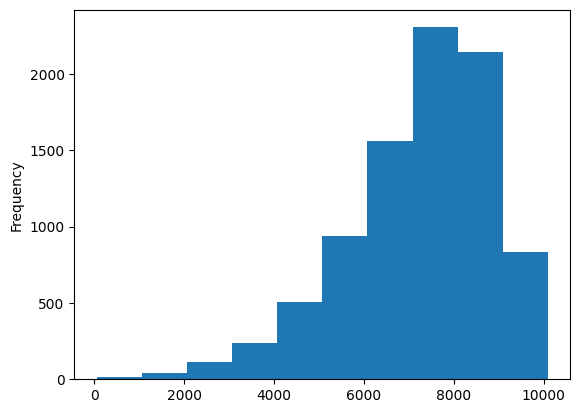

In [51]:
sm_df['posts'].apply(lambda p: len(p)).plot.hist()

In [39]:
sid.polarity_scores(sm_df['posts'][0])

{'neg': 0.057, 'neu': 0.832, 'pos': 0.111, 'compound': 0.9816}

In [28]:
sm_df = pd.read_csv('data/mbti.csv')
sm_df.shape

(8675, 3)

In [3]:
sm_df.columns

Index(['filename', 'type', 'posts'], dtype='str')

In [4]:
sm_df.value_counts('type')

type
INFP    1832
INFJ    1470
INTP    1304
INTJ    1091
ENTP     685
ENFP     675
ISTP     337
ISFP     271
ENTJ     231
ISTJ     205
ENFJ     190
ISFJ     166
ESTP      89
ESFP      48
ESFJ      42
ESTJ      39
Name: count, dtype: int64

In [26]:
sm_df['type'].apply(lambda s: [s[0], s[1], s[2], s[3]])

0       [I, N, F, J]
1       [E, N, T, P]
2       [I, N, T, P]
3       [I, N, T, J]
4       [E, N, T, J]
            ...     
8670    [I, S, F, P]
8671    [E, N, F, P]
8672    [I, N, T, P]
8673    [I, N, F, P]
8674    [I, N, F, P]
Name: type, Length: 8675, dtype: object

In [43]:
sm_df['sentiment']=sm_df['posts'].apply(lambda posts: sid.polarity_scores(posts)['compound'])

<Axes: ylabel='Frequency'>

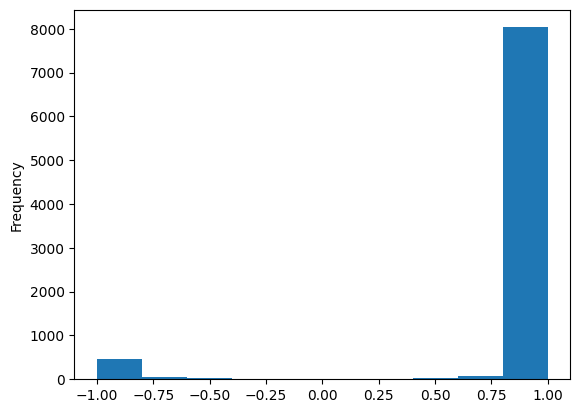

In [45]:
sm_df['sentiment'].plot.hist()

In [16]:
sm_df['type'].str.split('')[0]

['', 'I', 'N', 'F', 'J', '']

In [54]:
def length_of_post(text):
    return len(text)

In [55]:
sm_df['posts'].apply(length_of_post)

0       4652
1       7053
2       5265
3       6271
4       6111
        ... 
8670    5011
8671    7902
8672    5772
8673    9479
8674    7418
Name: posts, Length: 8675, dtype: int64

In [56]:
sm_df['posts'].apply(lambda x: len(x))

0       4652
1       7053
2       5265
3       6271
4       6111
        ... 
8670    5011
8671    7902
8672    5772
8673    9479
8674    7418
Name: posts, Length: 8675, dtype: int64